# Viability vs Gene Expression Change Analysis

**Goal**: Correlate bulk drug viability (from GDSC) with single-cell transcriptomic effect magnitude (from Sciplex3).

**Datasets**:
- `srivatsan20_sciplex3_w_emb.h5ad` — single-cell RNA-seq with pre-computed scVI embeddings (`X_state` in `obsm`)
- `GDSC_dataset.csv` — bulk viability values (0–1 normalized), Prophet format

**Pipeline**:
1. Load Sciplex3, inspect available embeddings
2. Fit PCA on `X_state` subsample (same approach as Tahoe notebook)
3. Compute per-(drug, cell_line) pseudobulk mean shift in PCA space → euclidean distance
4. Load GDSC viability for matching (drug, cell_line) pairs
5. Correlate euclidean distance vs GDSC viability

**Why X_state instead of raw genes**: `X_state` is a pre-computed scVI/foundation model embedding -denoised, lower-dimensional, more biologically meaningful than raw 58K gene counts. This mirrors the Tahoe notebook approach exactly.

## 1. Imports and Setup

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA
from tqdm import tqdm

DATA_PATH   = "/storage/pancellflow/data/srivatsan20_sciplex3_w_emb.h5ad"
GDSC_PATH   = "/storage/pancellflow/datasets/GDSC_dataset.csv"
RESULTS_DIR = "/storage/pancellflow/results/"
OUT_CSV     = os.path.join(RESULTS_DIR, "drug_expression_changes_xstate.csv")

N_SAMPLE  = 300000  # cells to subsample for PCA fitting
N_PCS     = 100     # PCA components on top of X_state
MIN_CELLS = 10     # minimum treated cells per (drug, cell_line)

## 2. Load Sciplex3 and Inspect Embeddings

In [2]:
adata = sc.read_h5ad(DATA_PATH, backed="r")
adata = adata[adata.obs["cell_line"] != "NA"].to_memory()

print(f"Cells : {adata.n_obs:,}")
print(f"Genes : {adata.n_vars:,}")
print(f"obsm keys : {list(adata.obsm.keys())}")
print(f"uns  keys : {list(adata.uns.keys())}")

Cells : 732,664
Genes : 58,302
obsm keys : ['X_scconcept', 'X_scgpt', 'X_scimilarity', 'X_scimilarity_correct', 'X_state']
uns  keys : ['cell_line_ccle_embedding_dim', 'cell_line_ccle_embeddings', 'cell_line_embedding_dim', 'cell_line_embeddings', 'drug_0_embeddings', 'drug_1_embeddings', 'drug_embedding_dim']


In [3]:
# Pick the embedding key — prefer X_state, fall back to X_scVI or X_pca
EMB_KEY = None
for key in ["X_state", "X_scVI", "X_scvi", "X_pca"]:
    if key in adata.obsm:
        EMB_KEY = key
        break

assert EMB_KEY is not None, f"No embedding found in obsm. Available: {list(adata.obsm.keys())}"

emb_dim = adata.obsm[EMB_KEY].shape[1]
print(f"Using embedding: '{EMB_KEY}' — {adata.n_obs:,} cells × {emb_dim}d")

Using embedding: 'X_state' — 732,664 cells × 2058d


In [4]:
# Split into control and treated
control = adata[adata.obs["pert_compound"] == "control"]
treated = adata[adata.obs["pert_compound"] != "control"]

print(f"Control : {control.n_obs:,}")
print(f"Treated : {treated.n_obs:,}")
print(f"\nControl per cell line:\n{control.obs['cell_line'].value_counts()}")
print(f"\nTreated per cell line:\n{treated.obs['cell_line'].value_counts()}")

# Build obs_name -> positional index map for fast slicing of obsm
obs_index = pd.Series(np.arange(adata.n_obs), index=adata.obs_names)

Control : 17,578
Treated : 715,086

Control per cell line:
MCF7     7786
A549     5857
K-562    3935
Name: cell_line, dtype: int64

Treated per cell line:
MCF7     323651
A549     228359
K-562    163076
Name: cell_line, dtype: int64


## 3. Fit PCA on X_state Subsample

`X_state` is already a compact embedding (e.g. 2058-dim from scVI/scGPT), so:
- No HVG selection needed
- No sparse→dense conversion
- PCA fitting is fast even on 20K cells

This is exactly what the Tahoe notebook does.

In [5]:
rng = np.random.default_rng(42)
idx = rng.choice(adata.n_obs, N_SAMPLE, replace=False)

X_sample = adata.obsm[EMB_KEY][idx].astype(np.float32)
print(f"PCA input shape: {X_sample.shape}")

pca = PCA(n_components=N_PCS, random_state=42)
pca.fit(X_sample)
del X_sample

print(f"Explained variance in {N_PCS} PCs: {pca.explained_variance_ratio_.sum():.1%}")

PCA input shape: (300000, 2058)
Explained variance in 100 PCs: 31.0%


## 4. Compute Per-(Drug, Cell Line) Pseudobulk Effect in X_state PCA Space

For each (drug, cell_line):
- Fetch `X_state` embeddings for control and treated cells
- Project into shared PCA space
- Euclidean distance between pseudobulk means = transcriptomic effect magnitude

In [6]:
results = []

for (drug, cell_line), group in tqdm(treated.obs.groupby(["pert_compound", "cell_line"])):
    ctrl_names  = control.obs[control.obs["cell_line"] == cell_line].index
    treat_names = group.index

    if len(treat_names) < MIN_CELLS:
        continue

    # Use positional index to slice obsm (faster than string indexing)
    ctrl_pos  = obs_index[ctrl_names].values
    treat_pos = obs_index[treat_names].values

    ctrl_emb  = adata.obsm[EMB_KEY][ctrl_pos].astype(np.float32)
    treat_emb = adata.obsm[EMB_KEY][treat_pos].astype(np.float32)

    ctrl_mean_pca  = pca.transform(ctrl_emb).mean(axis=0)
    treat_mean_pca = pca.transform(treat_emb).mean(axis=0)

    euclidean = np.linalg.norm(treat_mean_pca - ctrl_mean_pca)

    results.append({
        "drug"          : drug,
        "cell_line"     : cell_line,
        "n_control"     : len(ctrl_names),
        "n_treated"     : len(treat_names),
        "euclidean_dist": euclidean,
    })

results_df = pd.DataFrame(results)
results_df["drug_norm"]      = results_df["drug"].str.lower().str.strip()
results_df["cell_line_norm"] = results_df["cell_line"].str.lower().str.strip()

results_df.to_csv(OUT_CSV, index=False)
print(f"Saved {len(results_df)} (drug, cell_line) pairs")
results_df.head()

100%|███████████████████████████████████████████████████████████████████████| 540/540 [00:17<00:00, 30.21it/s]

Saved 540 (drug, cell_line) pairs


,drug,cell_line,n_control,n_treated,euclidean_dist,drug_norm,cell_line_norm
0,2-Methoxyestradiol,A549,5857,2428,0.064982,2-methoxyestradiol,a549
1,2-Methoxyestradiol,K-562,3935,738,0.026122,2-methoxyestradiol,k-562
2,2-Methoxyestradiol,MCF7,7786,1843,0.028819,2-methoxyestradiol,mcf7
3,A-366,A549,5857,982,0.061229,a-366,a549
4,A-366,K-562,3935,1057,0.016440,a-366,k-562


In [7]:
del adata
gc.collect()

0

## 5. Load GDSC Viability and Match

GDSC `value` = normalized viability (0–1) relative to DMSO.
- value ≈ 1.0 → no effect
- value ≈ 0.0 → strong effect (cell death)

Expected: **negative correlation** — more potent drug → lower viability + larger transcriptomic shift.

In [8]:
gdsc = pd.read_csv(GDSC_PATH)
gdsc["drug_norm"]      = gdsc["iv_name"].str.lower().str.strip()
gdsc["cell_line_norm"] = gdsc["cell_line"].str.lower().str.strip()

print(f"GDSC: {len(gdsc):,} rows | {gdsc['drug_norm'].nunique()} drugs | {gdsc['cell_line'].nunique()} cell lines")

# Check coverage for our 3 cell lines
for cl in results_df["cell_line_norm"].unique():
    n = gdsc["cell_line_norm"].str.contains(cl, na=False).sum()
    print(f"  '{cl}' in GDSC: {n} rows")

GDSC: 242,036 rows | 286 drugs | 967 cell lines
  'a549' in GDSC: 281 rows
  'k-562' in GDSC: 0 rows
  'mcf7' in GDSC: 283 rows


In [9]:
# Average GDSC viability per (drug, cell_line)
gdsc_viability = (
    gdsc.groupby(["drug_norm", "cell_line_norm"])["value"]
    .mean()
    .reset_index()
    .rename(columns={"value": "mean_viability"})
)

merged = results_df.merge(gdsc_viability, on=["drug_norm", "cell_line_norm"], how="inner").dropna()

print(f"Matched pairs : {len(merged)}")
print(f"Drugs matched : {merged['drug'].nunique()}")
print(f"Cell lines    : {merged['cell_line'].unique()}")
merged.head()

Matched pairs : 59
Drugs matched : 30
Cell lines    : ['A549' 'MCF7']


,drug,cell_line,n_control,n_treated,euclidean_dist,drug_norm,cell_line_norm,mean_viability
0,A-366,A549,5857,982,0.061229,a-366,a549,0.619652
1,A-366,MCF7,7786,1825,0.017293,a-366,mcf7,0.672613
2,Avagacestat,A549,5857,874,0.067366,avagacestat,a549,0.580336
3,Avagacestat,MCF7,7786,1759,0.041799,avagacestat,mcf7,0.662336
4,BMS-536924,A549,5857,728,0.057460,bms-536924,a549,0.428237


## 6. Correlation: Euclidean Distance (X_state) vs GDSC Viability

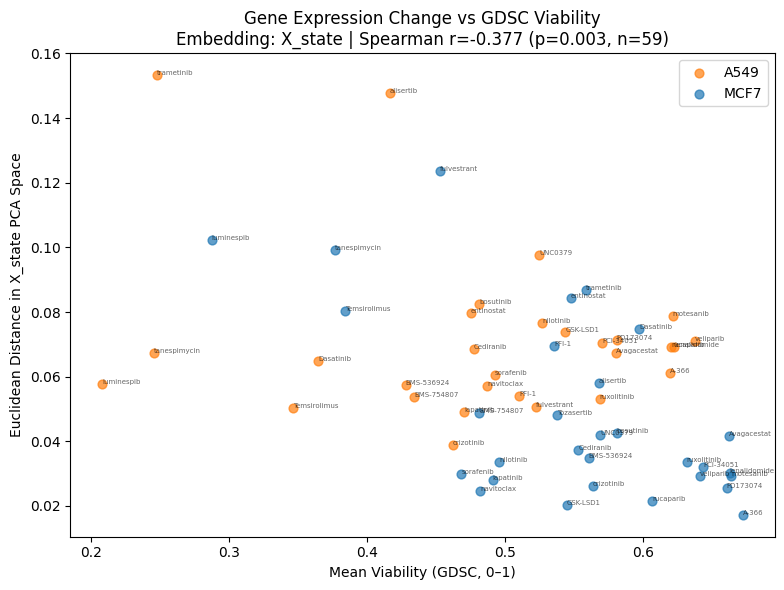

In [12]:
r_all, p_all = stats.spearmanr(merged["euclidean_dist"], merged["mean_viability"])

fig, ax = plt.subplots(figsize=(8, 6))
colors = {"MCF7": "#1f77b4", "A549": "#ff7f0e", "K-562": "#2ca02c"}

for cl, grp in merged.groupby("cell_line"):
    ax.scatter(grp["mean_viability"], grp["euclidean_dist"],
               label=cl, color=colors.get(cl, "gray"), alpha=0.7, s=40)
    for _, row in grp.iterrows():
        ax.annotate(row["drug"], (row["mean_viability"], row["euclidean_dist"]),
                    fontsize=5, alpha=0.6)

ax.set_xlabel("Mean Viability (GDSC, 0–1)")
ax.set_ylabel(f"Euclidean Distance in {EMB_KEY} PCA Space")
ax.set_title(f"Gene Expression Change vs GDSC Viability\n"
             f"Embedding: {EMB_KEY} | Spearman r={r_all:.3f} (p={p_all:.3f}, n={len(merged)})")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "corr_gdsc_xstate.png"), dpi=150)
plt.show()

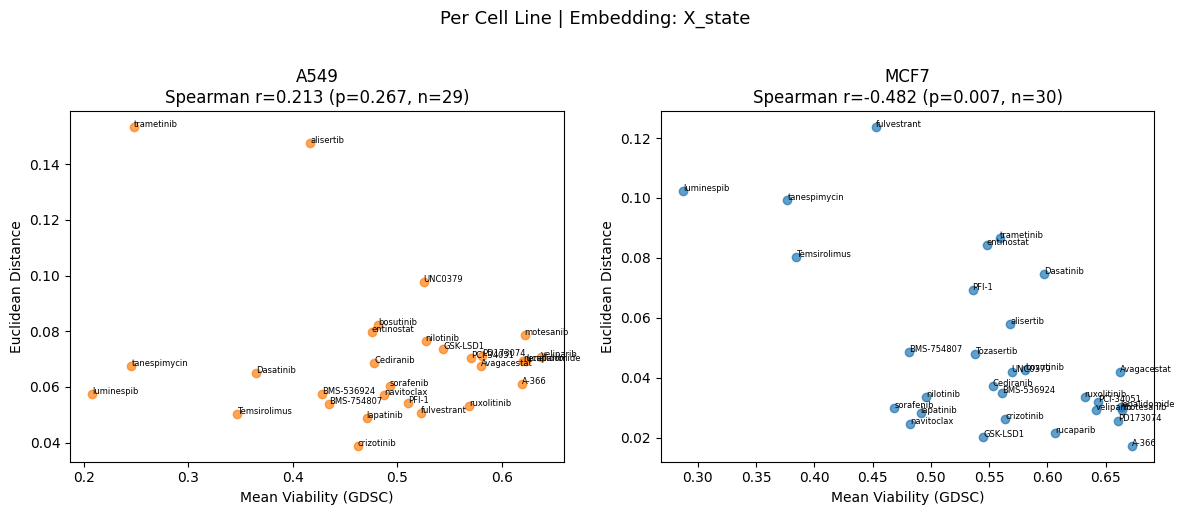

In [13]:
# Per cell line
cell_lines = merged["cell_line"].unique()
fig, axes = plt.subplots(1, len(cell_lines), figsize=(6 * len(cell_lines), 5))
if len(cell_lines) == 1:
    axes = [axes]

for ax, (cell_line, grp) in zip(axes, merged.groupby("cell_line")):
    if len(grp) < 3:
        continue
    r, p = stats.spearmanr(grp["euclidean_dist"], grp["mean_viability"])
    ax.scatter(grp["mean_viability"], grp["euclidean_dist"], alpha=0.7,
               color=colors.get(cell_line, "gray"))
    for _, row in grp.iterrows():
        ax.annotate(row["drug"], (row["mean_viability"], row["euclidean_dist"]), fontsize=6)
    ax.set_xlabel("Mean Viability (GDSC)")
    ax.set_ylabel("Euclidean Distance")
    ax.set_title(f"{cell_line}\nSpearman r={r:.3f} (p={p:.3f}, n={len(grp)})")

plt.suptitle(f"Per Cell Line | Embedding: {EMB_KEY}", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "corr_gdsc_xstate_per_cellline.png"), dpi=150)
plt.show()

In [14]:
# Inspect dose and time distribution to guide dose/time stratification
print("Dose values in Sciplex3 treated cells:")
print(treated.obs["dose_value"].value_counts().sort_index())

print("\nTime points:")
print(treated.obs["time"].value_counts())

Dose values in Sciplex3 treated cells:
10.0       194458
100.0      185103
1000.0     176164
10000.0    159361
Name: dose_value, dtype: int64

Time points:
24.0    638666
72.0     76420
Name: time, dtype: int64
